# Composite Images

For visualizing segmentation results, we want to overlay the cell boundaries on top of the images, so that we can evaluate the segmentation quality, look for over-/under-segmentation, etc.

In this notebook, we will use create composite RGB images from 3 channels, then overlay the segmentation on top

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import skimage 
import pandas as pd
import reprlib
from pathlib import Path
from tqdm.notebook import tqdm
from pathml.core import SlideData

## Load processed image

Here we load the `.h5path` file for an image which has already been preprocessed using the PathML pipeline

In [2]:
data_path = Path("/Users/jacobrosenthal/data/molecular_imaging_core")

# Ye's experiment
ye_path = data_path / "Exp022 20211206YT TNU19_titrate2/processed_2021-12-07/stitched/reg001"
wsi_path = ye_path / "redseafixed_20211206YT_Exp022_TNU19_titrate2.h5path"
channels_path = ye_path / "redseafixed_20211206YT_Exp022_TNU19_titrate2_h5path_channel_order.txt"

wsi = SlideData(str(wsi_path))


/opt/miniconda3/envs/codex/lib/python3.8/site-packages/anndata/_io/h5ad.py:64: FutureWarning: The `force_dense` argument is deprecated. Use `as_dense` instead.
  warn(


In [ ]:
# wsi = SlideData("/Users/jacobrosenthal/data/molecular_imaging_core/Exp. 270 - 102521SM-HNC14/processed_2021-10-26/pathml_analysis/redsea2_Exp. 270 - 102521SM-HNC14.h5path")
# wsi = SlideData("/Users/jacobrosenthal/data/molecular_imaging_core/Exp022 20211206YT TNU19_titrate2/processed_2021-12-07/stitched/reg001/redsea_20211206YT_Exp022_TNU19_titrate2.h5path")

load channel names from the file written by the PathML pipeline `*_channel_order.txt`

In [14]:
channels = pd.read_csv(channels_path, sep = "\t", header = None)
# channels = pd.read_csv("/Users/jacobrosenthal/data/molecular_imaging_core/Exp022 20211206YT TNU19_titrate2/processed_2021-12-07/stitched/reg001/redsea_20211206YT_Exp022_TNU19_titrate2_h5path_channel_order.txt", sep = "\t", header = None)

channel_names = list(channels[1].values)

print("loaded channels:", reprlib.repr(channel_names), "\n")

CD3e_ix = channel_names.index("CD3e")
CD20_ix = channel_names.index("CD20")
DAPI_ix = channel_names.index("DAPI-01")
print(f"DAPI channel index: {DAPI_ix}")
print(f"CD3e channel index: {CD3e_ix}")
print(f"CD20 channel index: {CD20_ix}")


loaded channels: ['DAPI-01', 'DAPI-03', 'DAPI-04', 'DAPI-05', 'DAPI-06', 'DAPI-07', ...] 

DAPI channel index: 0
CD3e channel index: 43
CD20 channel index: 65


## Visualize a single tile

Pull out a single tile from the `.h5path` file of the preprocessed image

In [4]:
tile = wsi.tiles[(824*4, 824*13)]

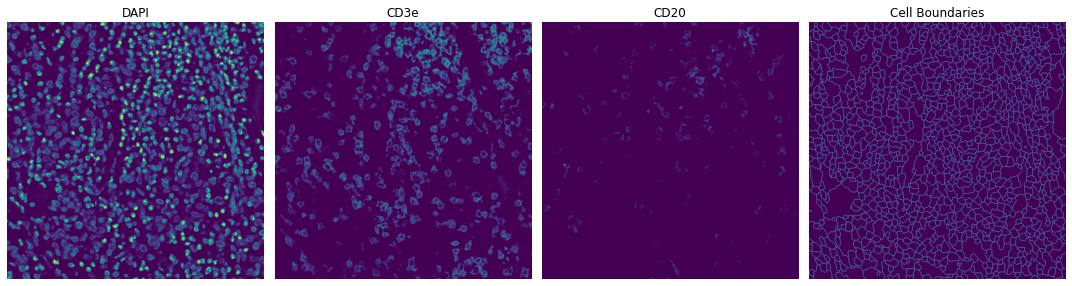

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize = (15, 5))
ax[0].imshow(tile.image[..., DAPI_ix]) # DAPI
ax[1].imshow(skimage.exposure.equalize_adapthist(tile.image[..., CD3e_ix].astype(np.uint16), clip_limit=0.03)) # CD3e
ax[2].imshow(skimage.exposure.equalize_adapthist(tile.image[..., CD20_ix].astype(np.uint16), clip_limit=0.03)) # CD20
#ax[2].imshow(tile.image[..., CD20_ix]) # CD20

mask = tile.masks["watershed"].astype(np.uint16).squeeze()
boundaries = skimage.segmentation.find_boundaries(mask, connectivity = 1, mode = "inner")
# this step thins out boundaries that are >1 px wide
boundaries = skimage.morphology.thin(boundaries)
ax[3].imshow(boundaries) # cell boundaries

ax[0].set_title("DAPI")
ax[1].set_title("CD3e")
ax[2].set_title("CD20")
ax[3].set_title("Cell Boundaries")

for a in ax: a.axis("off")

plt.tight_layout()
plt.show()

Now we make a composite image, combining the above single-channel images into a single RGB image, with each of the channels in a different color and the segmentation boundaries overlaid

The code for the visualization itself is contained in a separate file, called `composite_visualization.py`

In [7]:
from composite_visualization import plot_composite_segmentation

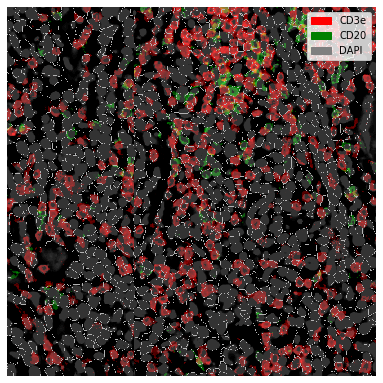

In [15]:
plot_composite_segmentation(tile=tile, mask_name="watershed", channel_names=channel_names, 
                            dapi=DAPI_ix, red=CD3e_ix, green=CD20_ix, blue=None)

Once satisfied with the results, plot composite images for all of the tiles for a processed image and save them:

In [177]:
for tile in tqdm(wsi.tiles):
    plot_composite_segmentation(tile=tile, mask_name="watershed", channel_names=channel_names, 
                            dapi=DAPI_ix, red=CD3e_ix, green=CD20_ix, blue=48, 
                            save_dir=ye_path / "segmentation results redseafixed_reg001_20211206YT_Exp022_TNU19_titrate2")

  0%|          | 0/288 [00:00<?, ?it/s]